In [1]:
# Import all necessary libraries.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import math  
from sklearn.metrics import silhouette_samples, silhouette_score

In [2]:
N = 1000
# Generating the sample data from make_blobs
X, y = make_blobs(n_samples=N, n_features=2, centers=4, cluster_std=1, center_box=(-10.0, 10.0), shuffle=True, random_state=1)

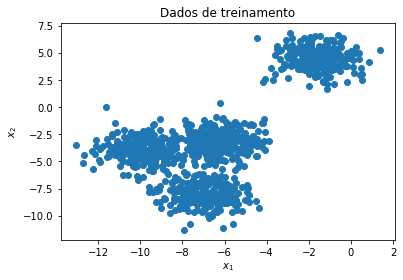

In [3]:
plt.scatter(X[:,0], X[:,1])
plt.title('Dados de treinamento')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

## Método do Cotovelo

In [4]:
wcss = []
for n in range(2, 21):
    kmeans = KMeans(n_clusters=n)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
sum_of_squares = wcss

x1, y1 = 2, wcss[0]
x2, y2 = 20, wcss[len(wcss)-1]

distances = []
for i in range(len(wcss)):
    x0 = i+2
    y0 = wcss[i]
    numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
    denominator = math.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    distances.append(numerator/denominator)

n_clusters = distances.index(max(distances)) + 2

print(n_clusters)

4


In [5]:
km = KMeans(n_clusters=n_clusters)
km.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [6]:
C1 = []
C2 = []
print('Valores ótimos para os Centroids:')
for i in range(0,n_clusters):
    C1.append(km.cluster_centers_[i][0])
    C2.append(km.cluster_centers_[i][1])
    print('Centroid%d: (%1.2f, %1.2f)' % (i,km.cluster_centers_[i][0],km.cluster_centers_[i][1]))

Valores ótimos para os Centroids:
Centroid0: (-1.61, 4.46)
Centroid1: (-9.90, -3.93)
Centroid2: (-6.21, -3.15)
Centroid3: (-6.98, -8.10)


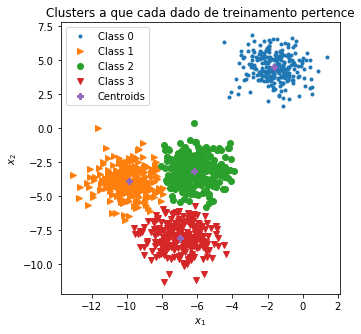

In [7]:
idx0 = np.argwhere(km.labels_ == 0)
idx1 = np.argwhere(km.labels_ == 1)
idx2 = np.argwhere(km.labels_ == 2)
idx3 = np.argwhere(km.labels_ == 3)

fig = plt.figure(figsize=(5,5))
plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], '>', label='Class 1')
plt.plot(X[idx2,0], X[idx2,1], 'o', label='Class 2')
plt.plot(X[idx3,0], X[idx3,1], 'v', label='Class 3')
plt.plot(C1,C2, 'P', label='Centroids')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Clusters a que cada dado de treinamento pertence')
plt.legend()
plt.show()

## Método da Silhueta

In [8]:
sil = []
kmax = 21
max_score = -2
n_clusters = -1
for k in range(2, 21):
    km2 = KMeans(n_clusters = k).fit(X)
    labels = km2.labels_
    score = silhouette_score(X, labels, metric = 'euclidean')
    if(max_score<score):
        max_score=score
        n_clusters = k
print(max_score)
print(n_clusters)

0.7047494651336347
2


In [9]:
km2 = KMeans(n_clusters=n_clusters)
km2.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=2, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [10]:
C1 = []
C2 = []
print('Valores ótimos para os Centroids:')
for i in range(0,n_clusters):
    C1.append(km2.cluster_centers_[i][0])
    C2.append(km2.cluster_centers_[i][1])
    print('Centroid%d: (%1.2f, %1.2f)' % (i,km2.cluster_centers_[i][0],km2.cluster_centers_[i][1]))

Valores ótimos para os Centroids:
Centroid0: (-7.74, -5.05)
Centroid1: (-1.61, 4.46)


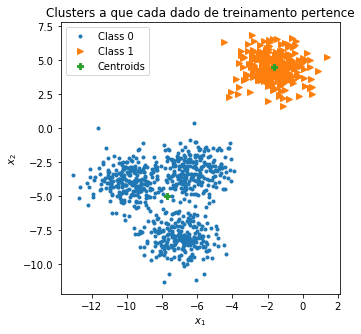

In [14]:
idx0 = np.argwhere(km2.labels_ == 0)
idx1 = np.argwhere(km2.labels_ == 1)

fig = plt.figure(figsize=(5,5))
plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], '>', label='Class 1')
plt.plot(C1,C2, 'P', label='Centroids')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Clusters a que cada dado de treinamento pertence')
plt.legend()
plt.show()